# COS760 — AI-Generated Text Detection in African Languages
### Group 22 | Edwin Nyaungwa (u23675022) · Thabang Kgosiemang (u20791535) · Sithembiso Masoka (u18189866)

**Research Questions:**
1. Which classifier performs best at detecting machine-generated text across African languages?
2. How effectively can a model transfer its detection ability to unseen / low-resource African languages?
3. What linguistic or syntactic features most reliably distinguish LLM-generated text from human-authored text?
4. How does performance vary across different African languages and datasets?

**Pipeline overview:**
- S1 Human data (Vukuzenzele + AfriSenti)
- S2 AI text generation (Groq · Gemini)
- S3 Dataset construction + stratified split
- S4 Baseline: TF-IDF + Logistic Regression
- S5 Main model: AfroXLMR fine-tuning
- S6 Full model comparison
- S7 Cross-lingual transfer tests
- S8 SHAP explainability
- S9 Linguistic feature analysis
- S10 Summary of findings


## Section 0 — Environment Setup

In [ ]:
# Mount Google Drive so every dataset, checkpoint, and result persists
# across Colab sessions. All project files live under one root folder.
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip uninstall -y torchvision torchaudio
!pip install -q sacremoses "datasets>=2.20.0"

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.


In [ ]:
# Define every project path in one place. Separating raw / processed /
# generated / models / results prevents accidental overwrites.
from pathlib import Path

BASE      = Path("/content/drive/MyDrive/COS760_Group22_Project")
RAW       = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"
GENERATED = BASE / "data" / "generated"
MODELS    = BASE / "models"
RESULTS   = BASE / "results"
REPOS     = BASE / "repos"

for p in [RAW, PROCESSED, GENERATED, MODELS, RESULTS, REPOS]:
    p.mkdir(parents=True, exist_ok=True)

print("All project directories ready.")
print(BASE)


All project directories ready.
/content/drive/MyDrive/COS760_Group22_Project


In [ ]:
# Standard imports shared by the whole notebook.
import pandas as pd
import numpy as np
import re, json, csv, os, random, time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Imports OK.")


Imports OK.


## Section 1 — Human Text Collection

Human-authored text is drawn from two sources that cover different registers:
- **Vukuzenzele** — formal South African government newsletter (Xhosa, Zulu, Sepedi)
- **AfriSenti** — informal social media tweets (Swahili)

Using two registers (formal + informal) prevents the classifier from learning
domain artefacts instead of genuine human-vs-machine signals.
All human texts receive label `0`.


In [ ]:
#                 Utility functions
# clean_text_column normalises whitespace, removes empty rows, deduplicates.
# split_into_sentences gives sentence-level granularity matching AfriSenti tweets,
# so human and machine texts are comparable in length.
import requests

def clean_text_column(df):
    df["text"] = (df["text"].astype(str)
                  .str.replace("\n", " ", regex=False)
                  .str.replace("\t", " ", regex=False)
                  .str.strip())
    df = df[df["text"].str.len() > 0].copy()
    df = df.drop_duplicates(subset=["text"])
    return df

def split_into_sentences(text):
    text = str(text).replace("\n", " ").strip()
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

print("Utility functions defined.")


Utility functions defined.


In [ ]:
#Vukuzenzele
# Articles are downloaded as JSONL from the DSFSI GitHub repository and split
# into sentences.  Each sentence becomes one training example (label=0).
def load_vukuzenzele(lang_code, lang_name):
    url = (f"https://raw.githubusercontent.com/dsfsi/vukuzenzele-nlp/master"
           f"/data/huggingface/{lang_code}/data.jsonl")
    r = requests.get(url, timeout=60)
    if r.status_code != 200:
        raise RuntimeError(f"Could not fetch {lang_code}: HTTP {r.status_code}")
    rows = []
    for line in r.text.splitlines():
        if line.strip():
            article = json.loads(line).get("text", "")
            for sent in split_into_sentences(article):
                rows.append({
                    "text": sent, "language": lang_name,
                    "language_code": lang_code,
                    "source": "vukuzenzele", "label": 0
                })
    return clean_text_column(pd.DataFrame(rows))

xhosa_df  = load_vukuzenzele("xho", "xhosa")
zulu_df   = load_vukuzenzele("zul", "zulu")
sepedi_df = load_vukuzenzele("nso", "sepedi")

for df, name in [(xhosa_df,"xhosa"),(zulu_df,"zulu"),(sepedi_df,"sepedi")]:
    df.to_csv(RAW / f"vukuzenzele_{name}_sentences.csv", index=False)
    print(f"{name}: {df.shape[0]:,} sentences")


xhosa: 4,167 sentences
zulu: 4,057 sentences
sepedi: 4,070 sentences


In [ ]:
#AfriSenti (Swahili)
# AfriSenti provides labelled tweets; we discard the sentiment label and keep
# only the text (label=0 for human).  All three splits are merged to maximise
# the human text pool for Swahili.
import subprocess

AFRISENTI_REPO = REPOS / "afrisent-semeval-2023"
if not AFRISENTI_REPO.exists():
    subprocess.run([
        "git","clone",
        "https://github.com/afrisenti-semeval/afrisent-semeval-2023",
        str(AFRISENTI_REPO)
    ], check=True)
else:
    print("AfriSenti repo already cloned.")

SWA_PATH = AFRISENTI_REPO / "data" / "swa"
parts = []
for fname in ["train.tsv","dev.tsv","test.tsv"]:
    fpath = SWA_PATH / fname
    if fpath.exists():
        tmp = pd.read_csv(fpath, sep="\t")
        parts.append(pd.DataFrame({
            "text": tmp["tweet"].astype(str),
            "language": "swahili", "language_code": "swa",
            "source": "afrisenti", "label": 0
        }))

swahili_df = clean_text_column(pd.concat(parts, ignore_index=True))
swahili_df.to_csv(RAW / "afrisenti_swahili.csv", index=False)
print(f"swahili: {swahili_df.shape[0]:,} tweets")


AfriSenti repo already cloned.
swahili: 2,999 tweets


In [ ]:
# Combine all human text
# Merge into a single clean file so later cells have one consistent source.
human_df = pd.concat(
    [xhosa_df, zulu_df, sepedi_df, swahili_df], ignore_index=True
)[["text","language","language_code","source","label"]]

human_df = clean_text_column(human_df)
human_df.to_csv(PROCESSED / "human_text_clean.csv", index=False)

print(f"Total human sentences: {len(human_df):,}")
print(human_df["language"].value_counts().to_string())
human_df.head()

Total human sentences: 15,269
language
xhosa      4167
sepedi     4058
zulu       4045
swahili    2999


,text,language,language_code,source,label
0,kwizikolo zikarhulumente eMzantsi Afrika banak...,xhosa,xho,vukuzenzele,0
1,Oku kwe- nzeka ngenxa yenkqubo ka- rhulumente ...,xhosa,xho,vukuzenzele,0
2,"ISebe leMfundo esiSise- ko (i-DBE), lisebenzis...",xhosa,xho,vukuzenzele,0
3,"Umlawuli we-NSNP ese- beni, uNeo Rakwena, uthi...",xhosa,xho,vukuzenzele,0
4,Uthi izikolo ezingaxha- mliyo kule nkqubo kufu...,xhosa,xho,vukuzenzele,0


## Section 2 — AI Text Generation

We prompt two LLMs (LLaMA 3.3 via Groq; Gemini 2.5 Flash) to produce African-language
text spanning 20 task types × 20 domains × 7 length styles.  This diversity prevents
the classifier from learning prompt-template artefacts instead of genuine
machine-writing signals.  Generated texts receive label `1`.

A checkpoint system writes each row immediately after generation, so the loop
can be interrupted and safely resumed at any point.


In [ ]:
#  Provider SDKs
!pip install -q --upgrade groq "google-genai>=1.66.0,<2.0.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.7/793.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 19.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.53.0 which is incompatible.


In [ ]:
# API keys
import os, getpass
os.environ["GROQ_API_KEY"]   = getpass.getpass("Groq API key:   ")
os.environ["GEMINI_API_KEY"] = getpass.getpass("Gemini API key: ")


Groq API key:   ··········
Gemini API key: ··········


In [ ]:
#           Load clients and seed data
# Seed texts provide topical context so generated content mirrors the same
# domains as our human corpus (formal government text + informal social media).
from groq import Groq
from google import genai
from google.genai import types

groq_client   = Groq(api_key=os.environ["GROQ_API_KEY"])
gemini_client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

human_df = pd.read_csv(PROCESSED / "human_text_clean.csv")
seed_df  = (human_df
            .groupby("language", group_keys=False)
            .apply(lambda g: g.sample(min(1000, len(g)), random_state=42))
            .reset_index(drop=True))
seed_df["seed_id"] = seed_df.index.astype(str)
seed_df.to_csv(PROCESSED / "gpt_seed_human_text.csv", index=False)
print(seed_df["language"].value_counts().to_string())


/tmp/ipykernel_502/2274624370.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(1000, len(g)), random_state=42))


language
sepedi     1000
swahili    1000
xhosa      1000
zulu       1000


In [ ]:
#                          Generation configuration
# Three temperatures per model introduce stylistic variation.
# Randomising from 20 task_types × 20 domains × 7 length_styles ensures
# the machine corpus covers a wide range of discourse types.
PROVIDERS = [
    {"provider":"groq",   "models":["llama-3.3-70b-versatile"],"temperatures":[0.7,0.9,1.1]},
    {"provider":"gemini", "models":["gemini-2.5-flash"],        "temperatures":[0.7,0.9,1.1]},
]
TASK_TYPES = [
    "question","complaint","request","opinion","casual_thought","academic_query",
    "shopping","technology","work","relationships","everyday_life",
    "rewrite","summarize","explain","educational","government_notice",
    "community_information","health_advice","public_service_message","short_story"
]
DOMAINS = [
    "weather and nature","food and cooking","family and relationships",
    "health and medicine","education and schools","government policies",
    "public services","social grants","community development",
    "elections and democracy","shopping and prices","phones and technology",
    "workplace issues","transport","housing","school applications",
    "clinic visits","water and electricity","youth unemployment","small businesses"
]
LENGTH_STYLES = [
    "one short sentence","two natural sentences","a short paragraph",
    "a longer paragraph","a message someone might send on a phone",
    "a formal paragraph","an informal paragraph"
]
print("Generation config ready.")


Generation config ready.


In [ ]:
#       Helper functions
# append_row_csv: writes and flushes a single row immediately so data is not
#   lost if the session disconnects.
# load_completed_keys: reads the output file to build a skip-set for resuming.
# clean_generated_text: removes whitespace and filters banned meta-language that
#   would leak the machine origin as a trivial feature to the classifier.

OUTPUT_FILE = GENERATED / "machine_text_multi_provider_raw.csv"
FAILED_FILE = GENERATED / "machine_text_generation_failures.csv"

OUTPUT_FIELDS = [
    "text","language","language_code","source","model",
    "temperature","generation_task","domain","length_style","seed_id","label"
]
FAILURE_FIELDS = [
    "provider","model","language","seed_id","generation_task","domain","length_style","error"
]
BANNED_PHRASES = [
    "as an ai","language model","dataset","classifier","generated text",
    "machine-generated","chatgpt","openai","gemini","groq"
]

def append_row_csv(path, row, fieldnames):
    exists = Path(path).exists()
    with open(path, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        if not exists:
            w.writeheader()
        w.writerow(row)
        f.flush()

def load_completed_keys():
    if not OUTPUT_FILE.exists():
        return set()
    df = pd.read_csv(OUTPUT_FILE)
    if df.empty:
        return set()
    for c in ["source","model","language","seed_id","generation_task","domain","length_style"]:
        if c not in df.columns:
            df[c] = ""
    return set(zip(df["source"],df["model"],df["language"],df["seed_id"],
                   df["generation_task"],df["domain"],df["length_style"]))

def clean_generated_text(text):
    text = " ".join(str(text).strip().replace("\n"," ").replace("\t"," ").split())
    lower = text.lower()
    for bp in BANNED_PHRASES:
        if bp in lower:
            return None
    return text if len(text) > 0 else None

print("Helper functions ready.")


Helper functions ready.


In [ ]:
#  Prompt builder
# Four randomised prompt templates reduce the risk that the classifier learns
# template-specific phrasing rather than genuine machine-writing signals.
def build_prompt(language, task, domain, length_style, seed_text):
    seed_text = str(seed_text)[:1000]
    templates = [
        f"Write naturally in {language}.\n\nSituation: {task}\nTopic: {domain}\n"
        f"Style: {length_style}\n\nUse the reference only as background context. "
        f"Do not copy it.\n\nReference:\n{seed_text}\n\nReturn only the final text.",

        f"Create a realistic piece of everyday writing in {language}.\n\n"
        f"It should sound like something a real person could write.\n"
        f"Context: {task}\nGeneral topic: {domain}\nLength/style: {length_style}\n\n"
        f"Use the background only for ideas, not wording.\n\n"
        f"Background:\n{seed_text}\n\nReturn only the text.",

        f"Write in {language} only.\n\nProduce a natural response for this scenario:\n"
        f"- Scenario type: {task}\n- Topic area: {domain}\n- Writing shape: {length_style}\n\n"
        f"The reference is only inspiration. Avoid repeating its wording.\n\n"
        f"Reference:\n{seed_text}\n\nReturn only the result.",

        f"In {language}, write something realistic and natural.\n\n"
        f"The writing should fit this use case: {task}.\n"
        f"The topic should relate to: {domain}.\n"
        f"The form should be: {length_style}.\n\n"
        f"Do not copy phrases from the reference.\n\n"
        f"Reference:\n{seed_text}\n\nReturn only the written text."
    ]
    return random.choice(templates)

print("Prompt builder ready.")


Prompt builder ready.


In [ ]:
# API call wrappers
SYSTEM_MSG = (
    "Write natural text only. Do not mention AI, models, datasets, "
    "classifiers, generation, or this instruction."
)

def call_groq(model, prompt, temperature):
    r = groq_client.chat.completions.create(
        model=model,
        messages=[{"role":"system","content":SYSTEM_MSG},
                  {"role":"user","content":prompt}],
        temperature=temperature, max_tokens=260
    )
    return r.choices[0].message.content

def call_gemini(model, prompt, temperature):
    r = gemini_client.models.generate_content(
        model=model, contents=prompt,
        config=types.GenerateContentConfig(
            temperature=temperature, max_output_tokens=260,
            system_instruction=SYSTEM_MSG
        )
    )
    return r.text

print("API call wrappers ready.")


API call wrappers ready.


In [ ]:
#  Generation loop
# Each iteration randomly selects provider / model / temperature / seed /
# task / domain / length_style.  The composite key prevents exact duplicates.
# Consecutive errors disable a provider; the loop ends gracefully when all
# providers are exhausted so it can be safely resumed from the checkpoint.

MAX_TOTAL       = 10000
MAX_CONSEC_ERR  = 5

seed_df    = pd.read_csv(PROCESSED / "gpt_seed_human_text.csv")
seed_df["seed_id"] = seed_df.index.astype(str)
completed  = load_completed_keys()
print(f"Already completed: {len(completed):,}")

prov_status = {p["provider"]: {"active": True, "errors": 0} for p in PROVIDERS}
total_gen   = 0
attempts    = 0

while total_gen < MAX_TOTAL and attempts < MAX_TOTAL * 20:
    attempts += 1
    active = [p for p in PROVIDERS if prov_status[p["provider"]]["active"]]
    if not active:
        print("All providers exhausted — stopping.")
        break

    pi    = random.choice(active)
    prov  = pi["provider"]
    model = random.choice(pi["models"])
    temp  = random.choice(pi["temperatures"])
    row   = seed_df.sample(1).iloc[0]
    lang  = row["language"]; lcode = row["language_code"]; sid = str(row["seed_id"])
    task  = random.choice(TASK_TYPES)
    dom   = random.choice(DOMAINS)
    sty   = random.choice(LENGTH_STYLES)
    key   = (prov, model, lang, sid, task, dom, sty)

    if key in completed:
        continue

    prompt = build_prompt(lang, task, dom, sty, row["text"])

    try:
        raw  = call_groq(model, prompt, temp) if prov == "groq" else call_gemini(model, prompt, temp)
        text = clean_generated_text(raw)
        if not text:
            raise ValueError("Banned phrase or empty output")

        append_row_csv(OUTPUT_FILE, {
            "text": text, "language": lang, "language_code": lcode,
            "source": prov, "model": model, "temperature": temp,
            "generation_task": task, "domain": dom,
            "length_style": sty, "seed_id": sid, "label": 1
        }, OUTPUT_FIELDS)

        completed.add(key)
        prov_status[prov]["errors"] = 0
        total_gen += 1
        if total_gen % 500 == 0:
            print(f"  Generated {total_gen:,} / {MAX_TOTAL:,}")

    except Exception as e:
        msg = str(e)
        prov_status[prov]["errors"] += 1
        if prov_status[prov]["errors"] >= MAX_CONSEC_ERR:
            prov_status[prov]["active"] = False
            print(f"{prov} disabled after {MAX_CONSEC_ERR} consecutive errors.")
        append_row_csv(FAILED_FILE, {
            "provider": prov, "model": model, "language": lang,
            "seed_id": sid, "generation_task": task, "domain": dom,
            "length_style": sty, "error": msg[:200]
        }, FAILURE_FIELDS)
        time.sleep(2)

print(f"\nSession total generated: {total_gen:,}")


Already completed: 2,575
gemini disabled after 5 consecutive errors.
groq disabled after 5 consecutive errors.
All providers exhausted — stopping.

Session total generated: 344


In [ ]:
#Clean machine-generated text
# Language-specific word-count filtering: keep machine texts whose length falls
# within the 5th–95th percentile of human text for that language (× 2 headroom).
# This removes very short garbage outputs and unusually verbose generations
# that would be trivially detectable by length alone.

human_df   = pd.read_csv(PROCESSED / "human_text_clean.csv")
machine_df = pd.read_csv(OUTPUT_FILE)
print("Raw machine shape:", machine_df.shape)

machine_df = machine_df.drop_duplicates(subset=["text"]).copy()
bad_pat    = "|".join(BANNED_PHRASES)
machine_df = machine_df[~machine_df["text"].str.lower().str.contains(bad_pat, na=False)].copy()

human_df["word_count"]   = human_df["text"].str.split().str.len()
machine_df["word_count"] = machine_df["text"].str.split().str.len()

filtered_parts = []
for lang in machine_df["language"].unique():
    h = human_df[human_df["language"] == lang]["word_count"]
    m = machine_df[machine_df["language"] == lang].copy()
    lo = max(3, int(h.quantile(0.05)))
    hi = min(int(h.quantile(0.95)) * 2, 200)
    kept = m[(m["word_count"] >= lo) & (m["word_count"] <= hi)]
    print(f"  {lang}: {len(m)} → {len(kept)} rows  (word range {lo}–{hi})")
    filtered_parts.append(kept)

machine_clean = pd.concat(filtered_parts, ignore_index=True)
machine_clean.to_csv(PROCESSED / "machine_text_clean.csv", index=False)
print("\nCleaned machine shape:", machine_clean.shape)
print(machine_clean["language"].value_counts().to_string())
machine_clean.head()


Raw machine shape: (2919, 11)
  xhosa: 772 → 731 rows  (word range 6–82)
  sepedi: 735 → 692 rows  (word range 10–144)
  swahili: 688 → 450 rows  (word range 5–68)
  zulu: 724 → 678 rows  (word range 6–82)

Cleaned machine shape: (2551, 12)
language
xhosa      731
sepedi     692
zulu       678
swahili    450


,text,language,language_code,source,model,temperature,generation_task,domain,length_style,seed_id,label,word_count
0,Abantu bathi amasebe afunyaniswe ngendlela efa...,xhosa,xho,groq,llama-3.3-70b-versatile,1.1,technology,government policies,two natural sentences,380,1,24
1,Ndicela undiphezele ngokwenza isithembu esinom...,xhosa,xho,groq,llama-3.3-70b-versatile,0.7,question,food and cooking,a short paragraph,672,1,43
2,Kulaphiwa abantu bokuthi bafikelele kwiindawo ...,xhosa,xho,groq,llama-3.3-70b-versatile,0.7,health_advice,government policies,a longer paragraph,852,1,72
3,Ndifuna ukuthetha ngebhangele ukuba abantu aba...,xhosa,xho,groq,llama-3.3-70b-versatile,0.7,shopping,workplace issues,two natural sentences,111,1,21
4,Ndiyaziqhenya ngokubanzi ukuthetha ngomndeni w...,xhosa,xho,groq,llama-3.3-70b-versatile,0.9,health_advice,family and relationships,a longer paragraph,243,1,72


## Section 3 — Dataset Construction and Stratified Split

We combine human (label=0) and machine (label=1) texts and create an 80/10/10
train/validation/test split stratified on label.

**Why 1.5× human?**  A modest 60/40 class imbalance reflects realistic deployment
conditions better than an artificial 50/50 split.  Macro F1 and class-balanced
training compensate for this imbalance.


In [ ]:
#    Build final balanced dataset
# For each language, sample ≈1.5 × as many human sentences as machine sentences
# to maintain a consistent imbalance ratio across all four languages.
from sklearn.model_selection import train_test_split

human_df   = pd.read_csv(PROCESSED / "human_text_clean.csv")
machine_df = pd.read_csv(PROCESSED / "machine_text_clean.csv")

human_parts = []
for lang in machine_df["language"].unique():
    ml = machine_df[machine_df["language"] == lang]
    hl = human_df[human_df["language"] == lang]
    n  = min(len(hl), int(len(ml) * 1.5))
    human_parts.append(hl.sample(n, random_state=42))

final_df = (pd.concat([pd.concat(human_parts), machine_df], ignore_index=True)
              .sample(frac=1, random_state=42)
              .reset_index(drop=True))
final_df.to_csv(PROCESSED / "final_dataset.csv", index=False)

print("Final dataset:", final_df.shape)
print("\nLabel distribution:")
print(final_df["label"].value_counts().to_string())
print("\nLanguage distribution:")
print(final_df["language"].value_counts().to_string())


Final dataset: (6377, 12)

Label distribution:
label
0    3826
1    2551

Language distribution:
language
xhosa      1827
sepedi     1730
zulu       1695
swahili    1125


In [ ]:
#    Stratified 80 / 10 / 10 split
# Stratifying on label ensures the same class ratio in every split, which is
# critical for valid evaluation metrics — especially on a small test set.

final_df = pd.read_csv(PROCESSED / "final_dataset.csv")

train_df, temp_df = train_test_split(
    final_df, test_size=0.20, random_state=42, stratify=final_df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"]
)

for df, name in [(train_df,"train"),(val_df,"validation"),(test_df,"test")]:
    df.to_csv(PROCESSED / f"{name}.csv", index=False)
    print(f"{name:12s}: {df.shape}  labels={dict(df['label'].value_counts())}")



train       : (5101, 12)  labels={0: np.int64(3060), 1: np.int64(2041)}
validation  : (638, 12)  labels={0: np.int64(383), 1: np.int64(255)}
test        : (638, 12)  labels={0: np.int64(383), 1: np.int64(255)}


In [ ]:
#just for reloading only after skipping s1 and s2
import pandas as pd
train_df = pd.read_csv(PROCESSED / "train.csv")
val_df   = pd.read_csv(PROCESSED / "validation.csv")
test_df  = pd.read_csv(PROCESSED / "test.csv")

X_train, y_train = train_df["text"].astype(str), train_df["label"]
X_val,   y_val   = val_df["text"].astype(str),   val_df["label"]
X_test,  y_test  = test_df["text"].astype(str),  test_df["label"]
print("Splits loaded.")

Splits loaded.


## Section 4 — Baseline Model: TF-IDF + Logistic Regression

The baseline captures surface-level n-gram patterns with TF-IDF and classifies
using logistic regression.  It is fast, transparent (essential for SHAP in S9),
and sets the benchmark AfroXLMR must exceed.

Metrics reported:
- Overall accuracy, macro F1, AUC-ROC
- **Per-language macro F1** (RQ4): ≥ 0.80 = pass
- Confusion matrix


In [ ]:
#     Load splits and train baseline
# TF-IDF unigrams + bigrams capture common phrases.
# class_weight="balanced" compensates for the 60/40 label imbalance.
# max_features=20,000 keeps the vocabulary manageable across four languages.

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score)

train_df = pd.read_csv(PROCESSED / "train.csv")
val_df   = pd.read_csv(PROCESSED / "validation.csv")
test_df  = pd.read_csv(PROCESSED / "test.csv")

X_train, y_train = train_df["text"].astype(str), train_df["label"]
X_val,   y_val   = val_df["text"].astype(str),   val_df["label"]
X_test,  y_test  = test_df["text"].astype(str),  test_df["label"]

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2), lowercase=True)),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])
baseline.fit(X_train, y_train)
print("Baseline model trained.")


Baseline model trained.


In [ ]:
# Save the trained Logistic Regression model to Google Drive.
# This means don't have to retrain it if the session restarts —
# can just load it back directly.

import joblib

joblib.dump(baseline, MODELS / "tfidf_lr_baseline.pkl")
print(f"Baseline model saved to: {MODELS / 'tfidf_lr_baseline.pkl'}")

Baseline model saved to: /content/drive/MyDrive/COS760_Group22_Project/models/tfidf_lr_baseline.pkl


In [ ]:
# # Load the saved Logistic Regression model back into memory.
# import joblib

# baseline = joblib.load(MODELS / "tfidf_lr_baseline.pkl")
# print("Baseline model loaded.")

In [ ]:
#     Overall evaluation + AUC-ROC
# AUC-ROC is threshold-independent and tells us how well the model ranks
# machine text above human text regardless of the decision threshold used.

test_pred  = baseline.predict(X_test)
test_proba = baseline.predict_proba(X_test)[:, 1]

baseline_acc   = accuracy_score(y_test, test_pred)
baseline_mf1   = f1_score(y_test, test_pred, average="macro")
baseline_auc   = roc_auc_score(y_test, test_proba)

print(f"Baseline — Accuracy: {baseline_acc:.4f} | Macro F1: {baseline_mf1:.4f} | AUC-ROC: {baseline_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))


Baseline — Accuracy: 0.9279 | Macro F1: 0.9241 | AUC-ROC: 0.9715

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       383
           1       0.93      0.88      0.91       255

    accuracy                           0.93       638
   macro avg       0.93      0.92      0.92       638
weighted avg       0.93      0.93      0.93       638

Confusion Matrix:
[[367  16]
 [ 30 225]]


In [ ]:
#    Per-language macro F1 and AUC-ROC
# Answers RQ4: "How does performance vary across different African languages?"
# We sets 0.80 as the pass threshold per language.

print("\t Baseline: Per-Language Breakdown   ")
baseline_per_lang = {}
for lang in sorted(test_df["language"].unique()):
    mask  = (test_df["language"] == lang).values
    lf1   = f1_score(y_test[mask], test_pred[mask], average="macro")
    lauc  = roc_auc_score(y_test[mask], test_proba[mask])
    status = "PASS" if lf1 >= 0.80 else "FAIL"
    baseline_per_lang[lang] = {"macro_f1": lf1, "auc_roc": lauc, "n": mask.sum()}
    print(f"  {lang:10s}: Macro F1={lf1:.4f}  AUC-ROC={lauc:.4f}  n={mask.sum()}  [{status}]")


res_bl = test_df.copy()
res_bl["bl_pred"]  = test_pred
res_bl["bl_proba"] = test_proba
res_bl.to_csv(RESULTS / "baseline_test_predictions.csv", index=False)
print("\nPredictions saved.")


	 Baseline: Per-Language Breakdown   
  sepedi    : Macro F1=0.9419  AUC-ROC=0.9758  n=180  [PASS]
  swahili   : Macro F1=0.8716  AUC-ROC=0.9472  n=108  [PASS]
  xhosa     : Macro F1=0.9582  AUC-ROC=0.9937  n=176  [PASS]
  zulu      : Macro F1=0.9034  AUC-ROC=0.9582  n=174  [PASS]

Predictions saved.


## Section 5 — AfroXLMR Fine-Tuning

`Davlan/afro-xlmr-base` is an XLM-R model further pre-trained on 17 African languages,
giving it richer sub-word vocabularies for Xhosa, Zulu, Sepedi, and Swahili than a
generic multilingual model.  We add a binary classification head and fine-tune for 3 epochs.

`load_best_model_at_end=True` + `metric_for_best_model="macro_f1"` ensures the final
checkpoint maximises the metric that matters for this imbalanced task.


In [ ]:
# Dependencies already handled in Section 0. Nothing to install here.
print("Dependencies ready.")

Dependencies ready.


In [ ]:
# Import Hugging Face libraries after restart so datasets==2.19.0 is active in memory.
import torch
import numpy as np
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)

print(f"PyTorch {torch.__version__}  |  GPU available: {torch.cuda.is_available()}")
print(f"Datasets version: {__import__('datasets').__version__}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch 2.12.0+cu130  |  GPU available: True
Datasets version: 4.8.5


In [ ]:
#   Load data + tokenize
# max_length=128 covers >95 % of texts in the dataset without wasting padding.

train_df = pd.read_csv(PROCESSED / "train.csv")
val_df   = pd.read_csv(PROCESSED / "validation.csv")
test_df  = pd.read_csv(PROCESSED / "test.csv")

MODEL_NAME = "Davlan/afro-xlmr-base"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length",
                     truncation=True, max_length=128)

def make_hf_dataset(df):
    ds = Dataset.from_pandas(df[["text","label"]])
    ds = ds.map(tokenize, batched=True)
    ds = ds.rename_column("label","labels").remove_columns(["text"])
    ds.set_format("torch")
    return ds

train_ds = make_hf_dataset(train_df)
val_ds   = make_hf_dataset(val_df)
test_ds  = make_hf_dataset(test_df)
print(train_ds)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/5101 [00:00<?, ? examples/s]

Map:   0%|          | 0/638 [00:00<?, ? examples/s]

Map:   0%|          | 0/638 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 5101
})


In [ ]:
#    Load AfroXLMR with classification head
# num_labels=2 adds a softmax classifier on top of the encoder pooler.
# The 'UNEXPECTED keys' warning is harmless — those are MLM head weights from
# pre-training that are correctly discarded for a classification task.

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(DEVICE)
print("AfroXLMR loaded onto", DEVICE)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AfroXLMR loaded onto cuda


In [ ]:
#  Training arguments
# Per-epoch evaluation lets us pick the best checkpoint rather than the last one,
# which is important when fine-tuning on a small dataset (~3,500 samples).
from sklearn.metrics import accuracy_score, f1_score

training_args = TrainingArguments(
    output_dir                  = str(MODELS / "afroxlmr_detector"),
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    num_train_epochs            = 3,
    weight_decay                = 0.01,
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",
    greater_is_better           = True,
    report_to                   = "none",
    save_total_limit            = 2,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

trainer = Trainer(
    model=model, args=training_args,
    train_dataset=train_ds, eval_dataset=val_ds,
    compute_metrics=compute_metrics
)
print("Trainer ready.")


Trainer ready.


In [ ]:
# Fine-tune AfroXLMR
trainer.train()



Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.103869,0.974922,0.973904
2,0.182709,0.117509,0.968652,0.967655
3,0.182709,0.158203,0.963950,0.962866


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=957, training_loss=0.13011275463841676, metrics={'train_runtime': 512.836, 'train_samples_per_second': 29.84, 'train_steps_per_second': 1.866, 'total_flos': 1006597120043520.0, 'train_loss': 0.13011275463841676, 'epoch': 3.0})

In [ ]:
# Overall evaluation + AUC-ROC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score)

predictions   = trainer.predict(test_ds)
afro_logits   = predictions.predictions
afro_proba    = torch.softmax(torch.tensor(afro_logits), dim=1).numpy()[:, 1]
afro_pred     = np.argmax(afro_logits, axis=1)
afro_true     = predictions.label_ids

afro_acc   = accuracy_score(afro_true, afro_pred)
afro_mf1   = f1_score(afro_true, afro_pred, average="macro")
afro_auc   = roc_auc_score(afro_true, afro_proba)

print(f"AfroXLMR — Accuracy: {afro_acc:.4f} | Macro F1: {afro_mf1:.4f} | AUC-ROC: {afro_auc:.4f}")
print("\nClassification Report:")
print(classification_report(afro_true, afro_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(afro_true, afro_pred))


AfroXLMR — Accuracy: 0.9577 | Macro F1: 0.9558 | AUC-ROC: 0.9885

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       383
           1       0.95      0.94      0.95       255

    accuracy                           0.96       638
   macro avg       0.96      0.95      0.96       638
weighted avg       0.96      0.96      0.96       638


Confusion Matrix:
[[371  12]
 [ 15 240]]


In [ ]:
# Per-language breakdown
# Critical for answering RQ4 and for the proposal's per-language 0.80 threshold.

print("\t AfroXLMR: Per-Language Breakdown")
afro_per_lang = {}
for lang in sorted(test_df["language"].unique()):
    mask  = (test_df["language"] == lang).values
    lf1   = f1_score(afro_true[mask], afro_pred[mask], average="macro")
    lauc  = roc_auc_score(afro_true[mask], afro_proba[mask])
    status = "PASS" if lf1 >= 0.80 else "FAIL"
    afro_per_lang[lang] = {"macro_f1": lf1, "auc_roc": lauc, "n": mask.sum()}
    print(f"  {lang:10s}: Macro F1={lf1:.4f}  AUC-ROC={lauc:.4f}  n={mask.sum()}  [{status}]")

# Persist predictions
res_afro = test_df.copy()
res_afro["afro_pred"]  = afro_pred
res_afro["afro_proba"] = afro_proba
res_afro.to_csv(RESULTS / "afroxlmr_test_predictions.csv", index=False)
print("\nSaved AfroXLMR predictions.")


	 AfroXLMR: Per-Language Breakdown
  sepedi    : Macro F1=0.9319  AUC-ROC=0.9839  n=180  [PASS]
  swahili   : Macro F1=0.9899  AUC-ROC=0.9981  n=108  [PASS]
  xhosa     : Macro F1=0.9642  AUC-ROC=0.9969  n=176  [PASS]
  zulu      : Macro F1=0.9520  AUC-ROC=0.9844  n=174  [PASS]

Saved AfroXLMR predictions.


In [ ]:
#     Error analysis
# Understanding where the model fails informs both RQ4 (language variation) and
# the linguistic analysis in §10 (what makes those texts hard to classify?).

errors = res_afro[res_afro["label"] != res_afro["afro_pred"]].copy()
errors.to_csv(RESULTS / "afroxlmr_errors.csv", index=False)

print(f"Total errors: {len(errors)} / {len(res_afro)}")
fp = ((errors["label"]==0) & (errors["afro_pred"]==1)).sum()
fn = ((errors["label"]==1) & (errors["afro_pred"]==0)).sum()
print(f"  False positives (human → machine): {fp}")
print(f"  False negatives (machine → human): {fn}")
print("\nErrors by language:")
print(errors["language"].value_counts().to_string())


Total errors: 27 / 638
  False positives (human → machine): 12
  False negatives (machine → human): 15

Errors by language:
language
sepedi     12
zulu        8
xhosa       6
swahili     1


## Section 6 — Full Model Comparison (RQ1)

**Research Question 1:** *"Which classifier performs best at detecting machine-generated
text across African languages?"*



In [ ]:
# Re-evaluate both trained models on the full test set for a clean comparison.
# GPTZero was excluded due to API access constraints — noted as a project limitation.

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

comparison_full = pd.DataFrame({
    "Model":    ["TF-IDF + LR (Baseline)", "AfroXLMR (Fine-tuned)"],
    "Accuracy": [round(baseline_acc, 4),   round(afro_acc, 4)],
    "Macro_F1": [round(baseline_mf1, 4),   round(afro_mf1, 4)],
    "AUC_ROC":  [round(baseline_auc, 4),   round(afro_auc, 4)],
})
print("=== Model Comparison (full test set) ===")
print(comparison_full.to_string(index=False))
comparison_full.to_csv(RESULTS / "model_comparison_full.csv", index=False)

=== Model Comparison (full test set) ===
                 Model  Accuracy  Macro_F1  AUC_ROC
TF-IDF + LR (Baseline)    0.9279    0.9241   0.9715
 AfroXLMR (Fine-tuned)    0.9577    0.9558   0.9885


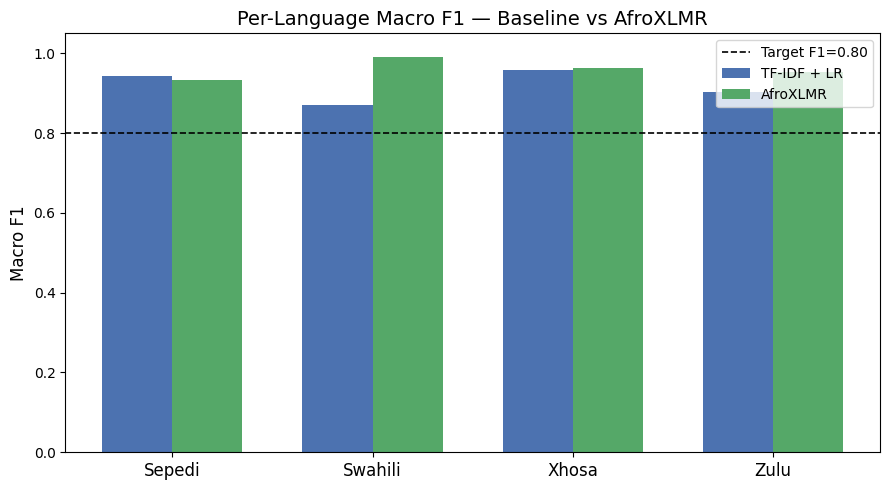

Chart saved.


In [ ]:
# Per-language macro F1 bar chart comparing both models.
# The dashed line marks the 0.80 pass threshold from the proposal.
import matplotlib.pyplot as plt
import numpy as np

langs     = sorted(test_df["language"].unique())
bl_vals   = [baseline_per_lang.get(l, {}).get("macro_f1", np.nan) for l in langs]
afro_vals = [afro_per_lang.get(l, {}).get("macro_f1", np.nan)     for l in langs]

x = np.arange(len(langs))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, bl_vals,   w, label="TF-IDF + LR", color="#4C72B0")
ax.bar(x + w/2, afro_vals, w, label="AfroXLMR",    color="#55A868")
ax.axhline(0.80, color="k", linestyle="--", lw=1.2, label="Target F1=0.80")
ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in langs], fontsize=12)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Per-Language Macro F1 — Baseline vs AfroXLMR", fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS / "per_language_f1_comparison.png", dpi=150)
plt.show()
print("Chart saved.")

## Section 7 — Cross-Lingual Transfer Tests (RQ2)

**Research Question 2:** *"How effectively can a model transfer its detection ability
to unseen or low-resource African languages?"*

In each scenario a model is trained on a subset of languages, then evaluated
**zero-shot** on a held-out language it has never seen.

| Scenario | Train | Zero-shot test | Rationale |
|---|---|---|---|
| A | Xhosa + Zulu | Sepedi | Nguni → Sotho-Tswana (same country, different family) |
| B | Xhosa + Zulu + Sepedi | Swahili | SA languages → East Africa |
| C | Sepedi + Swahili | Xhosa | Non-Nguni → Nguni |
| D | Xhosa + Sepedi + Swahili | Zulu | Ablation: leave Zulu out |

We first run all four scenarios with Logistic Regression (seconds each), then
re-run Scenarios A and B with AfroXLMR to show how multilingual pre-training helps.


In [ ]:
#   Logistic Regression transfer — all four scenarios
# LR is fast enough to run all four leave-one-language-out experiments quickly.
# These results form the baseline transfer comparison.

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

train_df = pd.read_csv(PROCESSED / "train.csv")
test_df  = pd.read_csv(PROCESSED / "test.csv")

TRANSFER_SCENARIOS = [
    (["xhosa","zulu"],              "sepedi",  "A — Nguni → Sotho"),
    (["xhosa","zulu","sepedi"],     "swahili", "B — SA → East Africa"),
    (["sepedi","swahili"],          "xhosa",   "C — Non-Nguni → Xhosa"),
    (["xhosa","sepedi","swahili"],  "zulu",    "D — Non-Zulu → Zulu"),
]

def lr_transfer(train_langs, test_lang):
    tr = train_df[train_df["language"].isin(train_langs)]
    te = test_df[test_df["language"] == test_lang]
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2))),
        ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ])
    pipe.fit(tr["text"].astype(str), tr["label"])
    pred  = pipe.predict(te["text"].astype(str))
    proba = pipe.predict_proba(te["text"].astype(str))[:,1]
    return {
        "scenario":    None,
        "train_langs": "+".join(train_langs),
        "test_lang":   test_lang,
        "n_train":     len(tr),
        "n_test":      len(te),
        "macro_f1":    round(f1_score(te["label"], pred, average="macro"), 4),
        "accuracy":    round(accuracy_score(te["label"], pred), 4),
        "auc_roc":     round(roc_auc_score(te["label"], proba), 4),
    }

lr_results = []
for train_l, test_l, label in TRANSFER_SCENARIOS:
    res = lr_transfer(train_l, test_l)
    res["scenario"] = label
    in_lang_f1 = baseline_per_lang.get(test_l, {}).get("macro_f1", float("nan"))
    res["in_lang_f1"] = round(in_lang_f1, 4)
    res["transfer_gap"] = round(in_lang_f1 - res["macro_f1"], 4)
    lr_results.append(res)
    print(f"{label}: zero-shot F1={res['macro_f1']:.4f}  in-lang={in_lang_f1:.4f}  gap={res['transfer_gap']:+.4f}")

lr_transfer_df = pd.DataFrame(lr_results)
lr_transfer_df.to_csv(RESULTS / "lr_transfer_results.csv", index=False)


A — Nguni → Sotho: zero-shot F1=0.3706  in-lang=0.9419  gap=+0.5713
B — SA → East Africa: zero-shot F1=0.7124  in-lang=0.8716  gap=+0.1592
C — Non-Nguni → Xhosa: zero-shot F1=0.4876  in-lang=0.9582  gap=+0.4706
D — Non-Zulu → Zulu: zero-shot F1=0.8242  in-lang=0.9034  gap=+0.0792


In [ ]:
#  AfroXLMR transfer — Scenario A (Nguni → Sepedi)
# This is the most theoretically interesting scenario: Xhosa and Zulu are Nguni
# languages; Sepedi is Sotho-Tswana.  AfroXLMR's multilingual pre-training
# should give it an advantage over LR in bridging this family gap.
# Training takes ~8 min on a Colab T4 GPU.

TR_A_LANGS = ["xhosa","zulu"]
TE_A_LANG  = "sepedi"

tr_a_df = train_df[train_df["language"].isin(TR_A_LANGS)]
te_a_df = test_df[test_df["language"] == TE_A_LANG]

tr_a_ds = make_hf_dataset(tr_a_df)
te_a_ds = make_hf_dataset(te_a_df)

model_a = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
args_a  = TrainingArguments(
    output_dir  = str(MODELS / "afro_transfer_a"),
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=16,
    per_device_eval_batch_size=16, num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    greater_is_better=True, report_to="none", save_total_limit=1,
)
trainer_a = Trainer(model=model_a, args=args_a,
                    train_dataset=tr_a_ds, eval_dataset=te_a_ds,
                    compute_metrics=compute_metrics)
trainer_a.train()
print("AfroXLMR Transfer A (Nguni → Sepedi) trained.")


Map:   0%|          | 0/2816 [00:00<?, ? examples/s]

Map:   0%|          | 0/180 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.253356,0.905556,0.902271
2,No log,0.370095,0.888889,0.886878
3,0.139752,0.290129,0.900000,0.897143


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

AfroXLMR Transfer A (Nguni → Sepedi) trained.


In [ ]:
#  Evaluate AfroXLMR Transfer A

pred_a      = trainer_a.predict(te_a_ds)
afro_a_pred = np.argmax(pred_a.predictions, axis=1)
afro_a_prob = torch.softmax(torch.tensor(pred_a.predictions),dim=1).numpy()[:,1]
afro_a_f1   = f1_score(pred_a.label_ids, afro_a_pred, average="macro")
afro_a_auc  = roc_auc_score(pred_a.label_ids, afro_a_prob)
in_lang_sep = afro_per_lang.get("sepedi",{}).get("macro_f1", float("nan"))

print(f"AfroXLMR Scenario A (Xhosa+Zulu → Sepedi):")
print(f"  Zero-shot Macro F1 : {afro_a_f1:.4f}  AUC-ROC: {afro_a_auc:.4f}")
print(f"  In-language F1     : {in_lang_sep:.4f}")
print(f"  Transfer gap       : {in_lang_sep - afro_a_f1:+.4f}")
lr_scen_a = lr_transfer_df[lr_transfer_df["test_lang"]=="sepedi"].iloc[0]
print(f"  LR zero-shot F1    : {lr_scen_a['macro_f1']:.4f}  (AfroXLMR advantage: {afro_a_f1-lr_scen_a['macro_f1']:+.4f})")


AfroXLMR Scenario A (Xhosa+Zulu → Sepedi):
  Zero-shot Macro F1 : 0.8967  AUC-ROC: 0.9589
  In-language F1     : 0.9319
  Transfer gap       : +0.0352
  LR zero-shot F1    : 0.3706  (AfroXLMR advantage: +0.5261)


In [ ]:
#  AfroXLMR transfer — Scenario B (SA Languages → Swahili)
# Swahili is geographically and structurally more distant from the SA languages;
# we expect a larger transfer gap here than in Scenario A, testing the limits
# of cross-lingual generalisation.

TR_B_LANGS = ["xhosa","zulu","sepedi"]
TE_B_LANG  = "swahili"

tr_b_df = train_df[train_df["language"].isin(TR_B_LANGS)]
te_b_df = test_df[test_df["language"] == TE_B_LANG]

tr_b_ds = make_hf_dataset(tr_b_df)
te_b_ds = make_hf_dataset(te_b_df)

model_b = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
args_b  = TrainingArguments(
    output_dir  = str(MODELS / "afro_transfer_b"),
    eval_strategy="epoch", save_strategy="epoch",
    learning_rate=2e-5, per_device_train_batch_size=16,
    per_device_eval_batch_size=16, num_train_epochs=3, weight_decay=0.01,
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    greater_is_better=True, report_to="none", save_total_limit=1,
)
trainer_b = Trainer(model=model_b, args=args_b,
                    train_dataset=tr_b_ds, eval_dataset=te_b_ds,
                    compute_metrics=compute_metrics)
trainer_b.train()
print("AfroXLMR Transfer B (SA Languages → Swahili) trained.")


Map:   0%|          | 0/4192 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.333131,0.824074,0.821488
2,0.180790,0.320696,0.805556,0.804196
3,0.180790,0.354522,0.805556,0.804196


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

AfroXLMR Transfer B (SA Languages → Swahili) trained.


In [ ]:
#  Evaluate AfroXLMR Transfer B + consolidated summary

pred_b      = trainer_b.predict(te_b_ds)
afro_b_pred = np.argmax(pred_b.predictions, axis=1)
afro_b_prob = torch.softmax(torch.tensor(pred_b.predictions),dim=1).numpy()[:,1]
afro_b_f1   = f1_score(pred_b.label_ids, afro_b_pred, average="macro")
afro_b_auc  = roc_auc_score(pred_b.label_ids, afro_b_prob)
in_lang_swa = afro_per_lang.get("swahili",{}).get("macro_f1", float("nan"))

print(f"AfroXLMR Scenario B (SA Languages → Swahili):")
print(f"  Zero-shot Macro F1 : {afro_b_f1:.4f}  AUC-ROC: {afro_b_auc:.4f}")
print(f"  In-language F1     : {in_lang_swa:.4f}")
print(f"  Transfer gap       : {in_lang_swa - afro_b_f1:+.4f}")

lr_scen_b = lr_transfer_df[lr_transfer_df["test_lang"]=="swahili"].iloc[0]
print(f"  LR zero-shot F1    : {lr_scen_b['macro_f1']:.4f}  (AfroXLMR advantage: {afro_b_f1-lr_scen_b['macro_f1']:+.4f})")

# Consolidated transfer table
transfer_summary = pd.DataFrame([
    {"Model":"AfroXLMR","Scenario":"A","Train":"+".join(TR_A_LANGS),
     "Test":TE_A_LANG,"Zero_shot_F1":round(afro_a_f1,4),
     "In_lang_F1":round(in_lang_sep,4),"AUC":round(afro_a_auc,4)},
    {"Model":"AfroXLMR","Scenario":"B","Train":"+".join(TR_B_LANGS),
     "Test":TE_B_LANG,"Zero_shot_F1":round(afro_b_f1,4),
     "In_lang_F1":round(in_lang_swa,4),"AUC":round(afro_b_auc,4)},
] + [{"Model":"TF-IDF+LR","Scenario":r["scenario"],"Train":r["train_langs"],
      "Test":r["test_lang"],"Zero_shot_F1":r["macro_f1"],
      "In_lang_F1":r["in_lang_f1"],"AUC":r["auc_roc"]} for _,r in lr_transfer_df.iterrows()])

print("\n=== Full Cross-Lingual Transfer Summary ===")
print(transfer_summary.to_string(index=False))
transfer_summary.to_csv(RESULTS / "cross_lingual_transfer_summary.csv", index=False)


AfroXLMR Scenario B (SA Languages → Swahili):
  Zero-shot Macro F1 : 0.8215  AUC-ROC: 0.9866
  In-language F1     : 0.9899
  Transfer gap       : +0.1684
  LR zero-shot F1    : 0.7124  (AfroXLMR advantage: +0.1091)

=== Full Cross-Lingual Transfer Summary ===
    Model              Scenario                Train    Test  Zero_shot_F1  In_lang_F1    AUC
 AfroXLMR                     A           xhosa+zulu  sepedi        0.8967      0.9319 0.9589
 AfroXLMR                     B    xhosa+zulu+sepedi swahili        0.8215      0.9899 0.9866
TF-IDF+LR     A — Nguni → Sotho           xhosa+zulu  sepedi        0.3706      0.9419 0.4342
TF-IDF+LR  B — SA → East Africa    xhosa+zulu+sepedi swahili        0.7124      0.8716 0.7259
TF-IDF+LR C — Non-Nguni → Xhosa       sepedi+swahili   xhosa        0.4876      0.9582 0.6504
TF-IDF+LR   D — Non-Zulu → Zulu xhosa+sepedi+swahili    zulu        0.8242      0.9034 0.9030


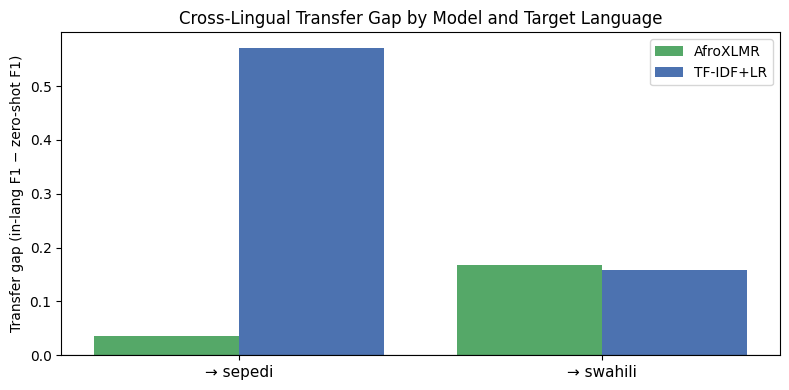

In [ ]:
#  Transfer gap visualisation
# A bar chart of transfer gap (in-language minus zero-shot F1) for AfroXLMR
# and LR shows how much performance degrades when the target language is unseen,
# and how much AfroXLMR pre-training reduces that degradation.

afro_rows = transfer_summary[transfer_summary["Model"]=="AfroXLMR"].copy()
lr_rows   = transfer_summary[transfer_summary["Model"]=="TF-IDF+LR"].copy()

scenarios_plot = afro_rows["Test"].tolist()
afro_gaps = (afro_rows["In_lang_F1"] - afro_rows["Zero_shot_F1"]).tolist()
lr_gaps   = [
    (lr_rows[lr_rows["Test"]==t]["In_lang_F1"].values[0] -
     lr_rows[lr_rows["Test"]==t]["Zero_shot_F1"].values[0])
    for t in scenarios_plot
]

x = np.arange(len(scenarios_plot))
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - 0.2, afro_gaps, 0.4, label="AfroXLMR", color="#55A868")
ax.bar(x + 0.2, lr_gaps,   0.4, label="TF-IDF+LR", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels([f"→ {l}" for l in scenarios_plot], fontsize=11)
ax.set_ylabel("Transfer gap (in-lang F1 − zero-shot F1)", fontsize=10)
ax.set_title("Cross-Lingual Transfer Gap by Model and Target Language")
ax.legend(); ax.axhline(0, color="k", lw=0.8)
plt.tight_layout()
plt.savefig(RESULTS / "transfer_gap_plot.png", dpi=150)
plt.show()


## Section 8 — SHAP Explainability (RQ3 support)

SHAP (SHapley Additive exPlanations) attributes each prediction to specific
input features, providing principled answers to RQ3.

- **For Logistic Regression** we use `shap.LinearExplainer` — exact and fast on
  sparse TF-IDF matrices.  The output is a ranked list of n-grams that most
  strongly indicate machine-generated vs human-authored text.
- **For AfroXLMR** we use `shap.Explainer` with a text masker on a 20-text sample.
  Token-level attributions show which words push predictions toward each class.


In [ ]:
# SHAP for Logistic Regression
# LinearExplainer computes exact SHAP values for linear models.
# We look at which n-grams most strongly push predictions toward
# "machine" (class 1) or "human" (class 0) to answer RQ3.

import shap
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("Agg")

tfidf_step = baseline.named_steps["tfidf"]
lr_step    = baseline.named_steps["clf"]
feat_names = tfidf_step.get_feature_names_out()

X_test_tfidf = tfidf_step.transform(X_test)

explainer_lr   = shap.LinearExplainer(lr_step, X_test_tfidf,
                                       feature_perturbation="interventional")
shap_values_lr = explainer_lr.shap_values(X_test_tfidf)

print(f"SHAP values type: {type(shap_values_lr)}")
if isinstance(shap_values_lr, list):
    print(f"Number of output arrays: {len(shap_values_lr)}")
    print(f"Shape per array: {np.array(shap_values_lr[0]).shape}")
else:
    print(f"Shape: {np.array(shap_values_lr).shape}")
print("LinearExplainer ready.")

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


SHAP values type: <class 'numpy.ndarray'>
Shape: (638, 20000)
LinearExplainer ready.


In [ ]:
# SHAP summary plot (LR)
# Red/right = pushes prediction toward class 1 (machine-generated).
# Blue/left  = pushes prediction toward class 0 (human-authored).
# The 20 features shown have the highest mean |SHAP| across all test instances.
#
# LinearExplainer for binary classification can return either:
#   - a list of 2 arrays (one per class), or
#   - a single 2D array of shape (n_samples, n_features)
# We always want the machine class values as a 2D matrix for the plot.

if isinstance(shap_values_lr, list):
    sv_plot = shap_values_lr[1]   # index 1 = machine class
else:
    sv_plot = shap_values_lr      # already the correct 2D shape

shap.summary_plot(
    sv_plot, X_test_tfidf,
    feature_names=feat_names,
    max_display=20,
    show=False
)
plt.title("SHAP — TF-IDF + LR: Top 20 Features (Class: Machine-Generated)")
plt.tight_layout()
plt.savefig(RESULTS / "shap_lr_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP LR summary plot saved.")

/tmp/ipykernel_28056/1852908376.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


SHAP LR summary plot saved.


In [ ]:
# Extract top 30 n-grams with the largest mean absolute SHAP value.
# Each feature is labelled with its direction: pushing toward machine or human.
# This directly answers RQ3 for the baseline model.

if isinstance(shap_values_lr, list):
    sv_class1 = np.array(shap_values_lr[1])
else:
    sv_class1 = np.array(shap_values_lr)

mean_shap = sv_class1.mean(axis=0)
top_idx   = np.argsort(np.abs(mean_shap))[::-1][:30]

top_feats = pd.DataFrame({
    "feature":   feat_names[top_idx],
    "mean_shap": mean_shap[top_idx],
    "direction": ["→ machine" if v > 0 else "→ human" for v in mean_shap[top_idx]],
    "abs_shap":  np.abs(mean_shap[top_idx])
}).sort_values("abs_shap", ascending=False)

print("Top 30 discriminating features (LR + TF-IDF):")
print(top_feats[["feature","mean_shap","direction"]].to_string(index=False))
top_feats.to_csv(RESULTS / "shap_lr_top_features.csv", index=False)

Top 30 discriminating features (LR + TF-IDF):
      feature  mean_shap direction
       abantu   0.032735 → machine
           ba  -0.029360   → human
           se   0.028030 → machine
        kunye  -0.013689   → human
         gore  -0.012080   → human
  ndingakwazi   0.010371 → machine
    ukuthenga  -0.010345   → human
          uku   0.010155 → machine
           ke  -0.009032   → human
        kanye   0.008330 → machine
       katika  -0.008258   → human
    ngokwenza  -0.008016   → human
          ili   0.007464 → machine
         baze  -0.007157   → human
ukuthuthukisa  -0.006786   → human
      ezifana  -0.006681   → human
          yam  -0.006096   → human
          kwa   0.006039 → machine
           ka   0.005915 → machine
        bethu   0.005901 → machine
          tla  -0.005848   → human
    ndiyacela   0.005776 → machine
           na   0.005713 → machine
       amanzi  -0.005595   → human
       muhimu  -0.005368   → human
    ni muhimu  -0.005361   → human
         

In [ ]:
# SHAP for AfroXLMR (20-text sample)
# TransformerExplainer is slow (~30-60s per text on GPU).
# We use 20 texts: 10 correctly classified + up to 10 misclassified.
# Token-level attributions reveal what the transformer learned vs the LR model.

import shap
import torch
import pandas as pd

model.eval()

def afro_predict_fn(texts):
    enc = tokenizer(
        list(texts), padding=True, truncation=True,
        max_length=128, return_tensors="pt"
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
    return torch.softmax(logits, dim=1).cpu().numpy()

# Load predictions saved earlier
res_afro = pd.read_csv(RESULTS / "afroxlmr_test_predictions.csv")

# Sample: 10 correct + up to 10 errors
correct_samp = res_afro[res_afro["label"] == res_afro["afro_pred"]].sample(10, random_state=7)
error_samp   = res_afro[res_afro["label"] != res_afro["afro_pred"]].head(10)
shap_sample  = pd.concat([correct_samp, error_samp]).reset_index(drop=True)
shap_texts   = shap_sample["text"].astype(str).tolist()[:20]

masker_txt     = shap.maskers.Text(tokenizer)
explainer_afro = shap.Explainer(
    afro_predict_fn, masker_txt,
    output_names=["Human", "Machine"]
)

print(f"Running SHAP on {len(shap_texts)} texts — please wait a few minutes...")
shap_vals_afro = explainer_afro(shap_texts, fixed_context=1, batch_size=4)
print("AfroXLMR SHAP done.")

Running SHAP on 20 texts — please wait a few minutes...


PartitionExplainer explainer: 21it [00:17,  1.56s/it]

AfroXLMR SHAP done.


In [ ]:
# AfroXLMR token-level attribution plots.
# Red tokens push the prediction toward 'Machine'.
# Blue tokens push the prediction toward 'Human'.
# Looking across multiple examples reveals systematic patterns
# that contribute to answering RQ3.

for i in range(min(5, len(shap_texts))):
    true_label = "machine" if shap_sample.iloc[i]["label"] == 1 else "human"
    pred_label = "machine" if shap_sample.iloc[i]["afro_pred"] == 1 else "human"
    correct    = "✓" if true_label == pred_label else "✗"
    print(f"\n--- Example {i+1} {correct} | True: {true_label} | Predicted: {pred_label} ---")
    print(f"Text: {shap_texts[i][:100]}...")
    shap.plots.text(shap_vals_afro[i, :, 1], display=True)  # index 1 = Machine class


--- Example 1 ✓ | True: human | Predicted: human ---
Text: Kufanele sigxile ekubhekaneni nezinselele ukuze sizozuza umphakathi okhululeke ngokweqi niso futhi o...



--- Example 2 ✓ | True: human | Predicted: human ---
Text: pole sana ndugu mteja tunaweza kujua eneo gani la Dar unakaa...



--- Example 3 ✓ | True: human | Predicted: human ---
Text: Se se hlotše hlo-tlo go batho bao ba nyakago go dira diteko mmogo le bao ba thomago kalafo ya di-ant...



--- Example 4 ✓ | True: human | Predicted: human ---
Text: Kumele isebenzele bona futhi bona kuphela....



--- Example 5 ✓ | True: machine | Predicted: machine ---
Text: Re a kopa hore puso e sekasekele melao yeo e kwalelago tokologo ya basadi le bana, gore e ba senkele...


## Section 9 — Linguistic Feature Analysis (RQ3)

**Research Question 3:** *"What linguistic or syntactic features most reliably
distinguish LLM-generated text from human-authored text in these languages?"*

Five surface features are computed for every text:

| Feature | What it captures |
|---|---|
| Type-Token Ratio (TTR) | Lexical diversity — lower = more repetitive |
| Mean word length | Vocabulary complexity |
| Sentence count | Structural complexity |
| Punctuation density | Formatting style |
| Word count | Text length |

Significance is tested using the Mann-Whitney U test (non-parametric, appropriate
for non-normal distributions).  We also examine per-language patterns and check
whether features correlate with AfroXLMR's confidence scores.


In [ ]:
#  Feature extraction functions
import re
import numpy as np
import pandas as pd
from scipy import stats

def type_token_ratio(text):
    toks = str(text).lower().split()
    return len(set(toks)) / len(toks) if toks else 0.0

def mean_word_length(text):
    words = str(text).split()
    return float(np.mean([len(w) for w in words])) if words else 0.0

def sentence_count(text):
    parts = re.split(r'[.!?]+', str(text).strip())
    return max(1, len([p for p in parts if p.strip()]))

def punctuation_density(text):
    text = str(text)
    return sum(1 for c in text if c in '.,!?;:') / len(text) if text else 0.0

LING_FEAT_FNS = {
    "ttr":           type_token_ratio,
    "mean_word_len": mean_word_length,
    "sent_count":    sentence_count,
    "punct_density": punctuation_density,
}

human_df   = pd.read_csv(PROCESSED / "human_text_clean.csv")
machine_df = pd.read_csv(PROCESSED / "machine_text_clean.csv")

for feat, fn in LING_FEAT_FNS.items():
    human_df[feat]   = human_df["text"].apply(fn)
    machine_df[feat] = machine_df["text"].apply(fn)

human_df["word_count"]   = human_df["text"].str.split().str.len()
machine_df["word_count"] = machine_df["text"].str.split().str.len()

ALL_FEATS = list(LING_FEAT_FNS.keys()) + ["word_count"]
print("Linguistic features extracted.")


Linguistic features extracted.


In [ ]:
#  Overall human vs machine comparison + Mann-Whitney U test
# The Mann-Whitney test checks whether the feature distribution differs
# significantly between the two classes.  p < 0.05 means the difference
# is statistically significant and the feature could help the classifier.

print("=== Feature Comparison: Human vs Machine ===")
ling_rows = []
for feat in ALL_FEATS:
    h = human_df[feat].dropna()
    m = machine_df[feat].dropna()
    _, p = stats.mannwhitneyu(h, m, alternative="two-sided")
    sig = ("***" if p < 0.001 else
           "**"  if p < 0.01  else
           "*"   if p < 0.05  else "ns")
    r = {"feature": feat,
         "human_mean":    round(float(h.mean()), 4),
         "human_std":     round(float(h.std()),  4),
         "machine_mean":  round(float(m.mean()), 4),
         "machine_std":   round(float(m.std()),  4),
         "p_value":       f"{p:.2e}",
         "significance":  sig}
    ling_rows.append(r)
    print(f"  {feat:18s}: human={h.mean():.3f}±{h.std():.2f}  "
          f"machine={m.mean():.3f}±{m.std():.2f}  p={p:.2e} {sig}")

ling_df = pd.DataFrame(ling_rows)
ling_df.to_csv(RESULTS / "linguistic_features_comparison.csv", index=False)


=== Feature Comparison: Human vs Machine ===
  ttr               : human=0.928±0.10  machine=0.830±0.16  p=4.10e-249 ***
  mean_word_len     : human=6.551±1.88  machine=6.535±1.88  p=7.30e-01 ns
  sent_count        : human=1.183±0.76  machine=2.121±1.27  p=0.00e+00 ***
  punct_density     : human=0.013±0.02  machine=0.017±0.01  p=2.79e-210 ***
  word_count        : human=22.477±18.61  machine=41.463±28.09  p=1.46e-308 ***


In [ ]:
#  Per-language linguistic feature comparison
# Differences between human and machine text may be stronger in some languages
# than others, contributing directly to the answer for RQ4.

all_texts = pd.concat([human_df, machine_df], ignore_index=True)

print("=== Per-Language Linguistic Means (Human | Machine) ===")
per_lang_ling = []
for lang in sorted(all_texts["language"].unique()):
    ld     = all_texts[all_texts["language"] == lang]
    h_sub  = ld[ld["label"] == 0]
    m_sub  = ld[ld["label"] == 1]
    print(f"\n  {lang.upper()}  (human n={len(h_sub)}  machine n={len(m_sub)})")
    for feat in ALL_FEATS:
        if len(h_sub) < 2 or len(m_sub) < 2:
            continue
        hm   = h_sub[feat].mean(); mm = m_sub[feat].mean()
        _, p = stats.mannwhitneyu(h_sub[feat].dropna(), m_sub[feat].dropna(),
                                   alternative="two-sided")
        sig  = ("***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns")
        print(f"    {feat:18s}: human={hm:.3f}  machine={mm:.3f}  diff={mm-hm:+.3f}  {sig}")
        per_lang_ling.append({"language":lang,"feature":feat,
                               "human_mean":round(hm,4),"machine_mean":round(mm,4),
                               "diff":round(mm-hm,4),"p_value":f"{p:.2e}","sig":sig})

pd.DataFrame(per_lang_ling).to_csv(RESULTS / "linguistic_features_per_language.csv", index=False)


=== Per-Language Linguistic Means (Human | Machine) ===

  SEPEDI  (human n=4058  machine n=692)
    ttr               : human=0.807  machine=0.654  diff=-0.153  ***
    mean_word_len     : human=4.402  machine=4.053  diff=-0.349  ***
    sent_count        : human=1.230  machine=2.120  diff=+0.890  ***
    punct_density     : human=0.016  machine=0.016  diff=+0.001  ***
    word_count        : human=33.305  machine=59.672  diff=+26.367  ***

  SWAHILI  (human n=2999  machine n=450)
    ttr               : human=0.940  machine=0.887  diff=-0.052  ***
    mean_word_len     : human=5.524  machine=5.564  diff=+0.040  **
    sent_count        : human=1.000  machine=1.662  diff=+0.662  ***
    punct_density     : human=0.000  machine=0.017  diff=+0.017  ***
    word_count        : human=16.948  machine=30.920  diff=+13.972  ***

  XHOSA  (human n=4167  machine n=731)
    ttr               : human=0.983  machine=0.901  diff=-0.082  ***
    mean_word_len     : human=7.905  machine=8.049  diff=

In [ ]:
#  Violin plots: TTR and word count by language
# Violin plots reveal the full distribution shape, not just the mean.
# TTR is theoretically motivated: LLMs tend to have more repetitive vocabulary
# than humans, particularly in low-resource languages.

import seaborn as sns
import matplotlib.pyplot as plt

all_texts["type"] = all_texts["label"].map({0: "Human", 1: "Machine"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat, title in zip(
    axes,
    ["ttr", "word_count"],
    ["Type-Token Ratio (Lexical Diversity)", "Word Count"]
):
    sns.violinplot(
        data=all_texts, x="language", y=feat, hue="type",
        split=True, inner="quartile",
        palette={"Human":"#4C72B0","Machine":"#C44E52"}, ax=ax
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Language"); ax.set_ylabel(feat)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Human vs Machine — Linguistic Feature Distributions", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS / "linguistic_violin_plots.png", dpi=150)
plt.show()
print("Violin plots saved.")


Violin plots saved.


In [ ]:
#  Correlation: linguistic features vs AfroXLMR confidence
# If the model has learned the linguistic signals identified above, then texts
# with lower TTR (more machine-like lexical diversity) should receive higher
# machine-probability scores from AfroXLMR.  A significant positive correlation
# validates that the transformer is using these features.

afro_test = pd.read_csv(RESULTS / "afroxlmr_test_predictions.csv")
for feat, fn in LING_FEAT_FNS.items():
    afro_test[feat] = afro_test["text"].apply(fn)
afro_test["word_count"] = afro_test["text"].str.split().str.len()

print("Pearson correlation: linguistic feature ↔ AfroXLMR machine probability")
corr_rows = []
for feat in ALL_FEATS:
    r, p = stats.pearsonr(afro_test[feat].fillna(0), afro_test["afro_proba"])
    sig  = ("***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns")
    print(f"  {feat:18s}: r={r:+.4f}  p={p:.2e}  {sig}")
    corr_rows.append({"feature":feat,"r":round(r,4),"p":f"{p:.2e}","sig":sig})

pd.DataFrame(corr_rows).to_csv(RESULTS / "linguistic_afro_correlation.csv", index=False)


Pearson correlation: linguistic feature ↔ AfroXLMR machine probability
  ttr               : r=-0.3411  p=7.49e-19  ***
  mean_word_len     : r=-0.0622  p=1.16e-01  ns
  sent_count        : r=+0.2095  p=9.29e-08  ***
  punct_density     : r=+0.2330  p=2.57e-09  ***
  word_count        : r=+0.2882  p=1.15e-13  ***


In [ ]:
#  Heatmap: per-language, per-feature mean difference (machine − human)
# A single heatmap summarises all per-language linguistic differences at once,
# making it easy to spot which features and languages show the largest signal.

pivot = (pd.DataFrame(per_lang_ling)
           .pivot(index="language", columns="feature", values="diff"))

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", center=0,
            cmap="RdBu_r", linewidths=0.5, ax=ax)
ax.set_title("Linguistic Feature Differences: Machine − Human (per language)", fontsize=12)
ax.set_xlabel("Feature"); ax.set_ylabel("Language")
plt.tight_layout()
plt.savefig(RESULTS / "linguistic_heatmap.png", dpi=150)
plt.show()
print("Heatmap saved.")


Heatmap saved.


## Section 10 — Summary of Findings

This section consolidates answers to all four research questions and prints
a complete results report ready to include in the final write-up.


In [ ]:
# Consolidated results summary answering all four research questions.
# Copy this output directly into the final report.

SEP = "=" * 70

print(SEP)
print("COS760 Group 22 — Final Results Summary")
print(SEP)

print("\n── RQ1: Which classifier performs best? ──────────────────────────")
print(comparison_full.to_string(index=False))

print("\n── RQ4: Performance variation across languages (AfroXLMR) ────────")
for lang, d in sorted(afro_per_lang.items()):
    status = "PASS ✓" if d["macro_f1"] >= 0.80 else "FAIL ✗"
    print(f"  {lang:10s}: Macro F1={d['macro_f1']:.4f}  AUC-ROC={d['auc_roc']:.4f}  [{status}]")

print("\n── RQ2: Cross-lingual transfer (AfroXLMR key scenarios) ──────────")
print(f"  Nguni (Xhosa+Zulu) → Sepedi  : zero-shot F1={afro_a_f1:.4f}  in-lang={in_lang_sep:.4f}  gap={in_lang_sep - afro_a_f1:+.4f}")
print(f"  SA languages       → Swahili : zero-shot F1={afro_b_f1:.4f}  in-lang={in_lang_swa:.4f}  gap={in_lang_swa - afro_b_f1:+.4f}")

print("\n── RQ3: Top linguistic discriminators (LR SHAP) ──────────────────")
for _, row in top_feats.head(5).iterrows():
    print(f"  '{row['feature']}'  {row['direction']}  (mean SHAP={row['mean_shap']:+.4f})")

print("\n── RQ3: Linguistic feature significance (Mann-Whitney U) ──────────")
for _, r in ling_df.iterrows():
    print(f"  {r['feature']:18s}: human={r['human_mean']:.3f}  machine={r['machine_mean']:.3f}  {r['significance']}")

print(f"\n✓ All results saved to: {RESULTS}")
print(SEP)

COS760 Group 22 — Final Results Summary

── RQ1: Which classifier performs best? ──────────────────────────
                 Model  Accuracy  Macro_F1  AUC_ROC
TF-IDF + LR (Baseline)    0.9279    0.9241   0.9715
 AfroXLMR (Fine-tuned)    0.9577    0.9558   0.9885

── RQ4: Performance variation across languages (AfroXLMR) ────────
  sepedi    : Macro F1=0.9319  AUC-ROC=0.9839  [PASS ✓]
  swahili   : Macro F1=0.9899  AUC-ROC=0.9981  [PASS ✓]
  xhosa     : Macro F1=0.9642  AUC-ROC=0.9969  [PASS ✓]
  zulu      : Macro F1=0.9520  AUC-ROC=0.9844  [PASS ✓]

── RQ2: Cross-lingual transfer (AfroXLMR key scenarios) ──────────
  Nguni (Xhosa+Zulu) → Sepedi  : zero-shot F1=0.8967  in-lang=0.9319  gap=+0.0352
  SA languages       → Swahili : zero-shot F1=0.8215  in-lang=0.9899  gap=+0.1684

── RQ3: Top linguistic discriminators (LR SHAP) ──────────────────
  'abantu'  → machine  (mean SHAP=+0.0327)
  'ba'  → human  (mean SHAP=-0.0294)
  'se'  → machine  (mean SHAP=+0.0280)
  'kunye'  → human  (mean